In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [80]:
df = pd.read_csv("../data/raw/fertilizer_data.csv")
df.head()


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


In [3]:
df.shape

(99, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Temparature      99 non-null     int64 
 1   Humidity         99 non-null     int64 
 2   Moisture         99 non-null     int64 
 3   Soil Type        99 non-null     object
 4   Crop Type        99 non-null     object
 5   Nitrogen         99 non-null     int64 
 6   Potassium        99 non-null     int64 
 7   Phosphorous      99 non-null     int64 
 8   Fertilizer Name  99 non-null     object
dtypes: int64(6), object(3)
memory usage: 7.1+ KB


In [5]:
df.describe()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,30.282828,59.151515,43.181818,18.909091,3.383838,18.606061
std,3.502304,5.840331,11.271568,11.599693,5.814667,13.476978
min,25.000000,50.000000,25.000000,4.000000,0.000000,0.000000
25%,28.000000,54.000000,34.000000,10.000000,0.000000,9.000000
50%,30.000000,60.000000,41.000000,13.000000,0.000000,19.000000
75%,33.000000,64.000000,50.500000,24.000000,7.500000,30.000000
max,38.000000,72.000000,65.000000,42.000000,19.000000,42.000000


In [6]:
df.columns

Index(['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')

In [7]:
df.sample(5)

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
73,27,53,34,Black,Oil seeds,42,0,0,Urea
65,36,68,62,Red,Cotton,15,0,40,DAP
81,30,60,40,Sandy,Millets,41,0,0,Urea
53,30,60,47,Sandy,Barley,12,0,42,DAP
85,35,67,28,Clayey,Pulses,8,7,31,14-35-14


In [8]:
df.isnull().sum()

Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["Fertilizer Name"].value_counts()

Fertilizer Name
Urea        22
DAP         18
28-28       17
14-35-14    14
20-20       14
17-17-17     7
10-26-26     7
Name: count, dtype: int64

## Target Variable Distribution

The target variable contains seven fertilizer categories.

The dataset is slightly imbalanced, with **Urea** having the highest number of samples (22), while **17-17-17** and **10-26-26** have the fewest samples (7 each). However, the class distribution is sufficiently balanced for building a multiclass classification model.

In [11]:
df.columns

Index(['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')

In [12]:
df.columns = df.columns.str.strip()

In [13]:
print(df.columns)

Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')


In [14]:
df.rename(columns={"Temparature": "Temperature"}, inplace=True)

In [15]:
print(df.columns)

Index(['Temperature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')


In [16]:
X = df.drop("Fertilizer Name", axis=1)
y = df["Fertilizer Name"]

In [17]:
categorical_cols = [
    "Soil Type",
    "Crop Type"
]

numerical_cols = [
    "Temperature",
    "Humidity",
    "Moisture",
    "Nitrogen",
    "Potassium",
    "Phosphorous"
]

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [19]:
y

array([6, 5, 1, 4, 6, 2, 3, 6, 4, 1, 5, 2, 6, 4, 5, 2, 6, 4, 6, 5, 3, 2,
       5, 6, 3, 4, 1, 6, 5, 3, 4, 5, 6, 1, 4, 6, 1, 5, 2, 5, 3, 1, 4, 6,
       5, 1, 3, 4, 6, 1, 4, 3, 6, 5, 2, 4, 6, 3, 2, 5, 6, 3, 4, 0, 6, 5,
       3, 1, 0, 3, 4, 6, 4, 6, 5, 1, 4, 3, 0, 5, 1, 6, 5, 3, 4, 1, 0, 6,
       0, 5, 1, 0, 6, 1, 4, 0, 6, 5, 3])

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [23]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Temperature','Humidity','Moisture',...,'Nitrogen','Potassium', 'Phosphorous']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [24]:
y_pred = lr_pipeline.predict(X_test)

In [25]:
y_pred

array([1, 6, 2, 1, 3, 6, 1, 5, 5, 0, 5, 4, 6, 3, 4, 6, 4, 6, 5, 3])

In [26]:
from sklearn.metrics import accuracy_score

train_acc = lr_pipeline.score(X_train, y_train)
test_acc = lr_pipeline.score(X_test, y_test)

print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)

Training Accuracy : 1.0
Testing Accuracy  : 1.0


<Figure size 800x600 with 0 Axes>

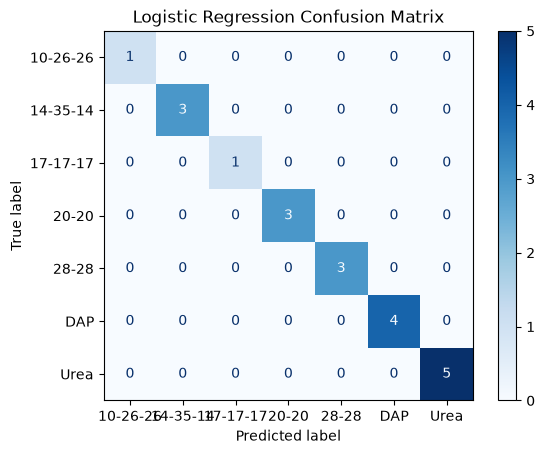

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

plt.figure(figsize=(8,6))
disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

    10-26-26       1.00      1.00      1.00         1
    14-35-14       1.00      1.00      1.00         3
    17-17-17       1.00      1.00      1.00         1
       20-20       1.00      1.00      1.00         3
       28-28       1.00      1.00      1.00         3
         DAP       1.00      1.00      1.00         4
        Urea       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [29]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=10,
    scoring="accuracy"
)

print("="*50)
print("Logistic Regression Cross Validation")
print("="*50)

print("CV Scores:")
print(cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Maximum Accuracy:", cv_scores.max())
print("Minimum Accuracy:", cv_scores.min())

Logistic Regression Cross Validation
CV Scores:
[1.  0.9 0.9 1.  1.  0.9 0.9 0.9 1.  1. ]

Mean CV Accuracy: 0.95
Maximum Accuracy: 1.0
Minimum Accuracy: 0.9


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Temperature','Humidity','Moisture',...,'Nitrogen','Potassium', 'Phosphorous']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [31]:
y_pred_dt = dt_pipeline.predict(X_test)

In [32]:
train_acc_dt = dt_pipeline.score(X_train, y_train)
test_acc_dt = dt_pipeline.score(X_test, y_test)

print("Training Accuracy :", train_acc_dt)
print("Testing Accuracy  :", test_acc_dt)

Training Accuracy : 1.0
Testing Accuracy  : 0.95


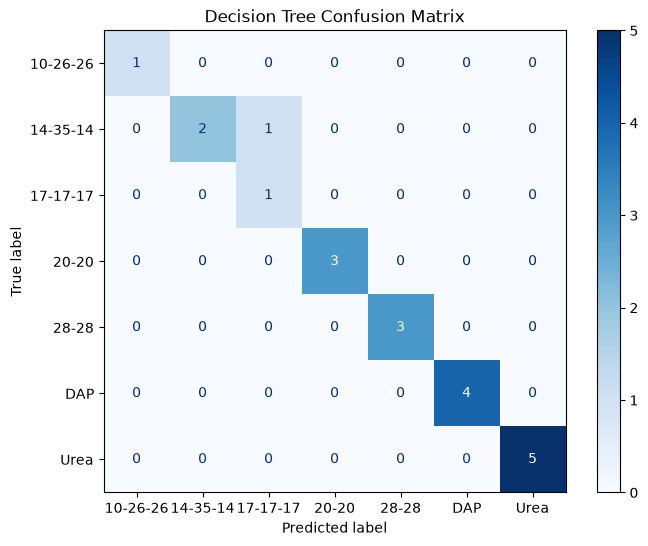

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [34]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=le.classes_
))

              precision    recall  f1-score   support

    10-26-26       1.00      1.00      1.00         1
    14-35-14       1.00      0.67      0.80         3
    17-17-17       0.50      1.00      0.67         1
       20-20       1.00      1.00      1.00         3
       28-28       1.00      1.00      1.00         3
         DAP       1.00      1.00      1.00         4
        Urea       1.00      1.00      1.00         5

    accuracy                           0.95        20
   macro avg       0.93      0.95      0.92        20
weighted avg       0.97      0.95      0.95        20



In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_dt = precision_score(y_test, y_pred_dt, average="weighted")
recall_dt = recall_score(y_test, y_pred_dt, average="weighted")
f1_dt = f1_score(y_test, y_pred_dt, average="weighted")

print("Precision :", precision_dt)
print("Recall    :", recall_dt)
print("F1 Score  :", f1_dt)

Precision : 0.975
Recall    : 0.95
F1 Score  : 0.9533333333333334


In [36]:
from sklearn.model_selection import cross_val_score

cv_scores_dt = cross_val_score(
    dt_pipeline,
    X,
    y,
    cv=10,
    scoring="accuracy"
)

print("="*50)
print("Decision Tree Cross Validation")
print("="*50)

print("CV Scores:")
print(cv_scores_dt)

print("\nMean CV Accuracy :", cv_scores_dt.mean())
print("Maximum Accuracy :", cv_scores_dt.max())
print("Minimum Accuracy :", cv_scores_dt.min())

Decision Tree Cross Validation
CV Scores:
[1.  1.  0.9 1.  0.9 0.9 1.  0.9 1.  1. ]

Mean CV Accuracy : 0.96
Maximum Accuracy : 1.0
Minimum Accuracy : 0.9


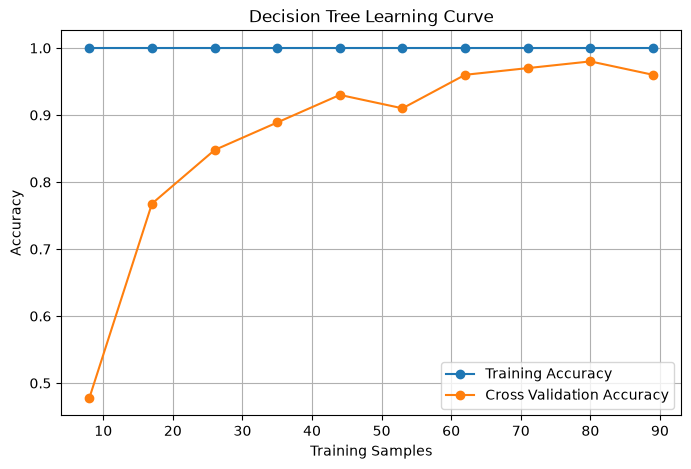

In [37]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    dt_pipeline,
    X,
    y,
    cv=10,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker="o", label="Cross Validation Accuracy")

plt.title("Decision Tree Learning Curve")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
import pandas as pd

dt_results = pd.DataFrame({
    "Metric":[
        "Training Accuracy",
        "Testing Accuracy",
        "Cross Validation",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value":[
        train_acc_dt,
        test_acc_dt,
        cv_scores_dt.mean(),
        precision_dt,
        recall_dt,
        f1_dt
    ]
})

dt_results

,Metric,Value
0,Training Accuracy,1.000000
1,Testing Accuracy,0.950000
2,Cross Validation,0.960000
3,Precision,0.975000
4,Recall,0.950000
5,F1 Score,0.953333


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Temperature','Humidity','Moisture',...,'Nitrogen','Potassium', 'Phosphorous']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [40]:
y_pred_rf = rf_pipeline.predict(X_test)

In [41]:
train_acc_rf = rf_pipeline.score(X_train, y_train)
test_acc_rf = rf_pipeline.score(X_test, y_test)

print("Training Accuracy :", train_acc_rf)
print("Testing Accuracy  :", test_acc_rf)

Training Accuracy : 1.0
Testing Accuracy  : 1.0


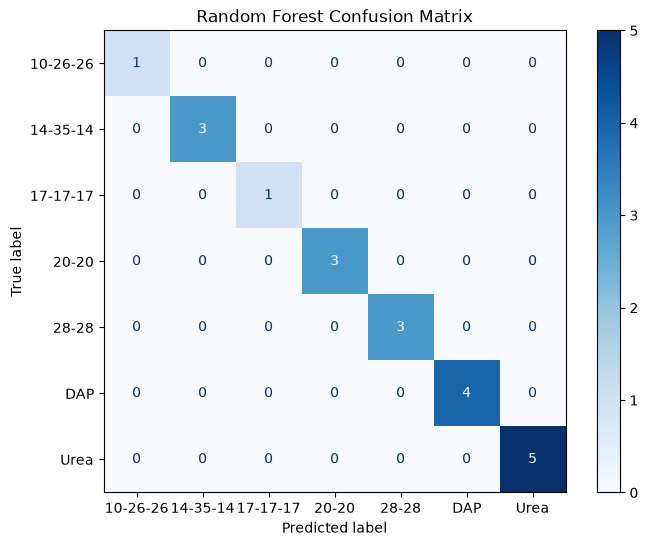

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=le.classes_
))

              precision    recall  f1-score   support

    10-26-26       1.00      1.00      1.00         1
    14-35-14       1.00      1.00      1.00         3
    17-17-17       1.00      1.00      1.00         1
       20-20       1.00      1.00      1.00         3
       28-28       1.00      1.00      1.00         3
         DAP       1.00      1.00      1.00         4
        Urea       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [63]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

In [49]:
from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=10,
    scoring="accuracy"
)

print("="*50)
print("Random Forest Cross Validation")
print("="*50)

print(cv_scores_rf)

print("\nMean CV Accuracy :", cv_scores_rf.mean())
print("Maximum Accuracy :", cv_scores_rf.max())
print("Minimum Accuracy :", cv_scores_rf.min())

Random Forest Cross Validation
[1.  0.9 1.  1.  1.  1.  0.9 0.9 1.  1. ]

Mean CV Accuracy : 0.97
Maximum Accuracy : 1.0
Minimum Accuracy : 0.9


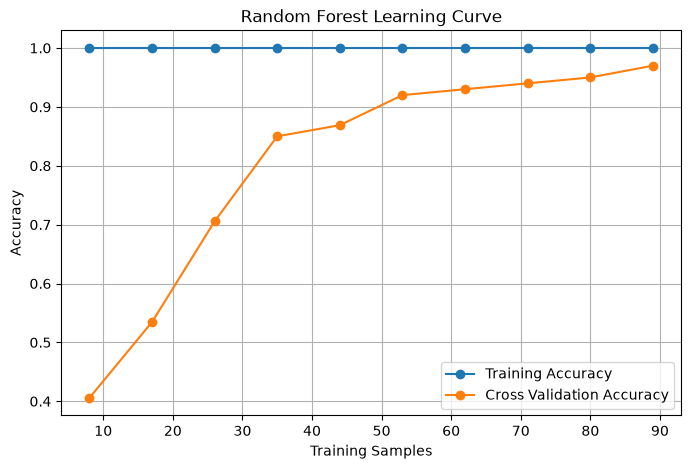

In [50]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    rf_pipeline,
    X,
    y,
    cv=10,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker="o", label="Cross Validation Accuracy")
plt.title("Random Forest Learning Curve")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [64]:
rf_results = pd.DataFrame({
    "Metric":[
        "Training Accuracy",
        "Testing Accuracy",
        "Cross Validation",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value":[
        train_acc_rf,
        test_acc_rf,
        cv_scores_rf.mean(),
        precision_rf,
        recall_rf,
        f1_rf
    ]
})

rf_results

,Metric,Value
0,Training Accuracy,1.00
1,Testing Accuracy,1.00
2,Cross Validation,0.97
3,Precision,1.00
4,Recall,1.00
5,F1 Score,1.00


In [52]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric="mlogloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](7,)","[0,1,2,...,4,5,6]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Temperature','Humidity','Moisture',...,'Nitrogen','Potassium', 'Phosphorous']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [53]:
y_pred_xgb = xgb_pipeline.predict(X_test)

In [54]:
train_acc_xgb = xgb_pipeline.score(X_train, y_train)
test_acc_xgb = xgb_pipeline.score(X_test, y_test)

print("Training Accuracy :", train_acc_xgb)
print("Testing Accuracy  :", test_acc_xgb)

Training Accuracy : 1.0
Testing Accuracy  : 1.0


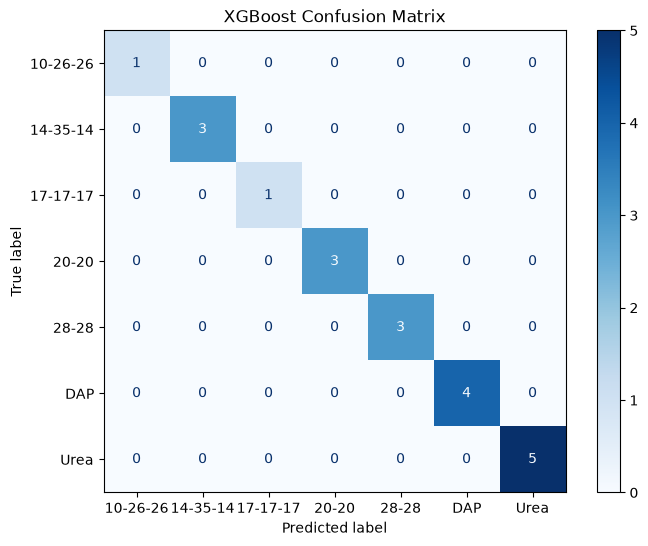

In [55]:
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap="Blues", ax=ax)
plt.title("XGBoost Confusion Matrix")
plt.show()

In [56]:
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=le.classes_
))

              precision    recall  f1-score   support

    10-26-26       1.00      1.00      1.00         1
    14-35-14       1.00      1.00      1.00         3
    17-17-17       1.00      1.00      1.00         1
       20-20       1.00      1.00      1.00         3
       28-28       1.00      1.00      1.00         3
         DAP       1.00      1.00      1.00         4
        Urea       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [65]:
precision_xgb = precision_score(y_test, y_pred_xgb, average="weighted")
recall_xgb = recall_score(y_test, y_pred_xgb, average="weighted")
f1_xgb = f1_score(y_test, y_pred_xgb, average="weighted")

In [58]:
cv_scores_xgb = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=10,
    scoring="accuracy"
)

print("="*50)
print("XGBoost Cross Validation")
print("="*50)

print(cv_scores_xgb)

print("\nMean CV Accuracy :", cv_scores_xgb.mean())
print("Maximum Accuracy :", cv_scores_xgb.max())
print("Minimum Accuracy :", cv_scores_xgb.min())

XGBoost Cross Validation
[1.  0.9 1.  1.  0.9 1.  1.  1.  1.  1. ]

Mean CV Accuracy : 0.9800000000000001
Maximum Accuracy : 1.0
Minimum Accuracy : 0.9


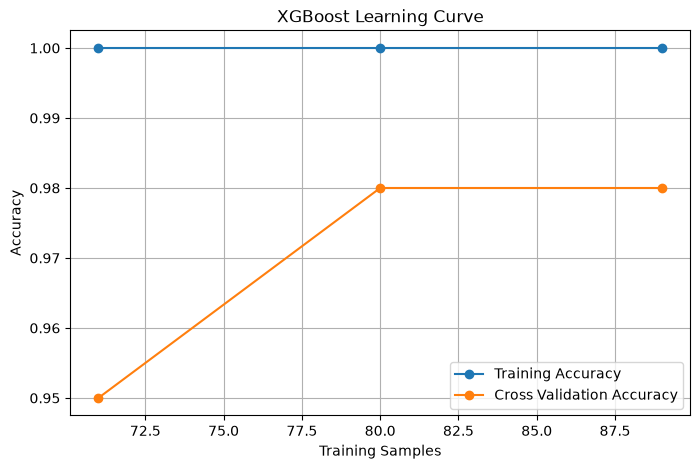

In [59]:
train_sizes, train_scores, test_scores = learning_curve(
    xgb_pipeline,
    X,
    y,
    cv=10,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy")
plt.plot(train_sizes, test_mean, marker="o", label="Cross Validation Accuracy")
plt.title("XGBoost Learning Curve")
plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [67]:
xgb_results = pd.DataFrame({
    "Metric":[
        "Training Accuracy",
        "Testing Accuracy",
        "Cross Validation",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value":[
        train_acc_xgb,
        test_acc_xgb,
        cv_scores_xgb.mean(),
        precision_xgb,
        recall_xgb,
        f1_xgb
    ]
})

xgb_results

,Metric,Value
0,Training Accuracy,1.00
1,Testing Accuracy,1.00
2,Cross Validation,0.98
3,Precision,1.00
4,Recall,1.00
5,F1 Score,1.00


## Model Comparison

Three machine learning algorithms were evaluated for fertilizer recommendation.

- Decision Tree achieved 95% testing accuracy but showed slight overfitting.
- Random Forest achieved 100% testing accuracy with 97% cross-validation accuracy.
- XGBoost achieved 100% testing accuracy and the highest cross-validation accuracy of 98%.

Based on the overall performance, **XGBoost** was selected as the final model for deployment due to its superior generalization performance.

> ⚠️ **Caveat:** the fertilizer dataset has only 99 rows total (~20 in the test split). 100% test accuracy on a set this small is expected to be optimistic — it likely reflects that this dataset follows a fairly deterministic soil/crop → fertilizer lookup rule rather than noisy real-world variation. Cross-validation (10-fold, above) is a more trustworthy signal than the single train/test split, and even that should be read with the small-data caveat in mind. Treat this model as a proof-of-concept, and validate against a larger, independently collected dataset before any real deployment.

In [68]:
feature_names = xgb_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(feature_names)

['num__Temperature' 'num__Humidity' 'num__Moisture' 'num__Nitrogen'
 'num__Potassium' 'num__Phosphorous' 'cat__Soil Type_Black'
 'cat__Soil Type_Clayey' 'cat__Soil Type_Loamy' 'cat__Soil Type_Red'
 'cat__Soil Type_Sandy' 'cat__Crop Type_Barley' 'cat__Crop Type_Cotton'
 'cat__Crop Type_Ground Nuts' 'cat__Crop Type_Maize'
 'cat__Crop Type_Millets' 'cat__Crop Type_Oil seeds'
 'cat__Crop Type_Paddy' 'cat__Crop Type_Pulses' 'cat__Crop Type_Sugarcane'
 'cat__Crop Type_Tobacco' 'cat__Crop Type_Wheat']


In [69]:
import pandas as pd

feature_importance_xgb = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_pipeline.named_steps["classifier"].feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb

,Feature,Importance
3,num__Nitrogen,0.386246
4,num__Potassium,0.354930
5,num__Phosphorous,0.247123
6,cat__Soil Type_Black,0.007762
2,num__Moisture,0.003939
1,num__Humidity,0.000000
0,num__Temperature,0.000000
7,cat__Soil Type_Clayey,0.000000
8,cat__Soil Type_Loamy,0.000000
9,cat__Soil Type_Red,0.000000


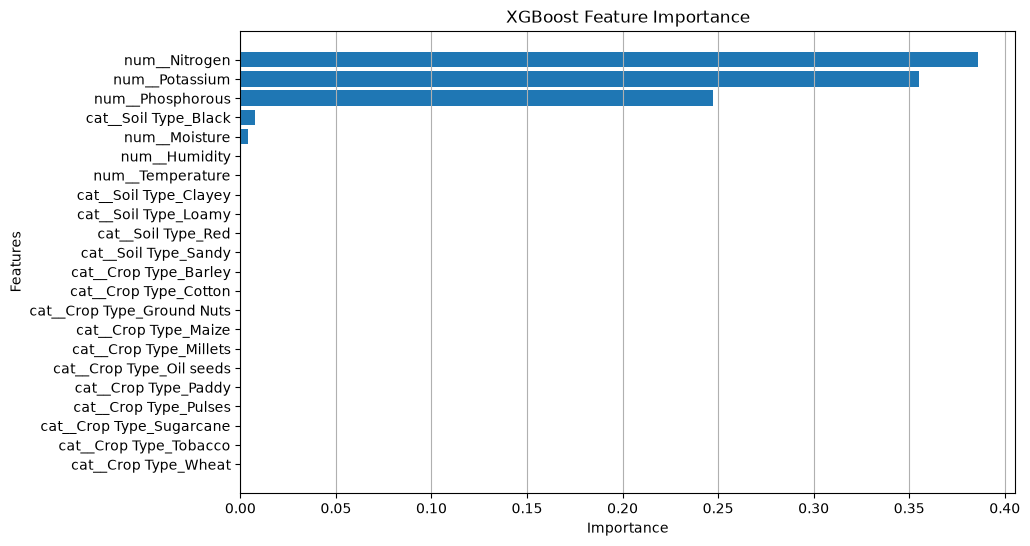

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_xgb["Feature"],
    feature_importance_xgb["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.grid(axis="x")

plt.show()

In [71]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_importance_rf = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_pipeline.named_steps["classifier"].feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf

,Feature,Importance
5,num__Phosphorous,0.307066
3,num__Nitrogen,0.228015
4,num__Potassium,0.140302
2,num__Moisture,0.069222
0,num__Temperature,0.056142
1,num__Humidity,0.052384
19,cat__Crop Type_Sugarcane,0.014169
6,cat__Soil Type_Black,0.013325
9,cat__Soil Type_Red,0.013300
8,cat__Soil Type_Loamy,0.013217


### Random Forest Feature Importance

Random Forest identified **Phosphorous**, **Nitrogen**, and **Potassium** as the three most influential features. Unlike XGBoost, Random Forest also assigned small importance to environmental factors such as Temperature, Humidity, Moisture, Soil Type, and Crop Type.

Although the ranking differs slightly from XGBoost, both models consistently indicate that the NPK nutrient values are the primary factors for fertilizer recommendation.

In [72]:
import os
import joblib

# Models folder create karega agar pehle se na ho
os.makedirs("../models", exist_ok=True)

# XGBoost Pipeline Save
joblib.dump(
    xgb_pipeline,
    "../models/fertilizer_model.pkl"
)

print("✅ Fertilizer Recommendation Model Saved Successfully!")

✅ Fertilizer Recommendation Model Saved Successfully!


In [73]:
joblib.dump(
    le,
    "../models/fertilizer_label_encoder.pkl"
)

print("✅ Label Encoder Saved Successfully!")

✅ Label Encoder Saved Successfully!
